# Varshini — Step 5

**Calibo AI Academy — Phase 1, Mini Use Case 01**
**Prepared by: Varshini**

In [1]:
# Import the libraries needed for data handling, math, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean grid style and a readable default figure size for every chart.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# Show large numbers with thousands separators instead of scientific notation.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Load the retail sales dataset from the project folder (relative path).
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
print(df.head())


  transaction_id        date store_id  ... unit_price   revenue discount_pct
0      TXN000001  2026-01-01      S01  ...   3,075.46  5,843.37            5
1      TXN000002  2026-01-01      S01  ...  11,598.06 11,598.06            0
2      TXN000003  2026-01-01      S01  ...   5,738.37 15,493.60           10
3      TXN000004  2026-01-01      S01  ...   3,281.28  9,351.65            5
4      TXN000005  2026-01-01      S01  ...   1,917.14  1,917.14            0

[5 rows x 10 columns]


In [3]:
# Convert the date column into a true datetime type so later steps can use it.
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("date column dtype after conversion:", df["date"].dtype)


Date range: 2026-01-01 to 2026-06-30
date column dtype after conversion: datetime64[us]


In [4]:
# Extract a "YYYY-MM" month label from each transaction date.
df["month"] = df["date"].dt.to_period("M").astype(str)

# Sum revenue by month and category, then reshape so each category is its own column.
cat_month_revenue = (
    df.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
    .pivot(index="month", columns="category", values="revenue")
)
cat_month_revenue


## Step 5 — Day-of-Week and Monthly Patterns
**Owner: Varshini**

We look at when revenue is strongest during the week and across the six months, to inform when
promotions and supplier-funded campaigns should be timed.


In [5]:
# Extract the day name for every transaction and set a Mon-Sun display order.
df["day_of_week"] = df["date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

avg_daily_revenue_by_weekday = (
    df.groupby("day_of_week")["revenue"].mean().reindex(weekday_order)
)
avg_daily_revenue_by_weekday


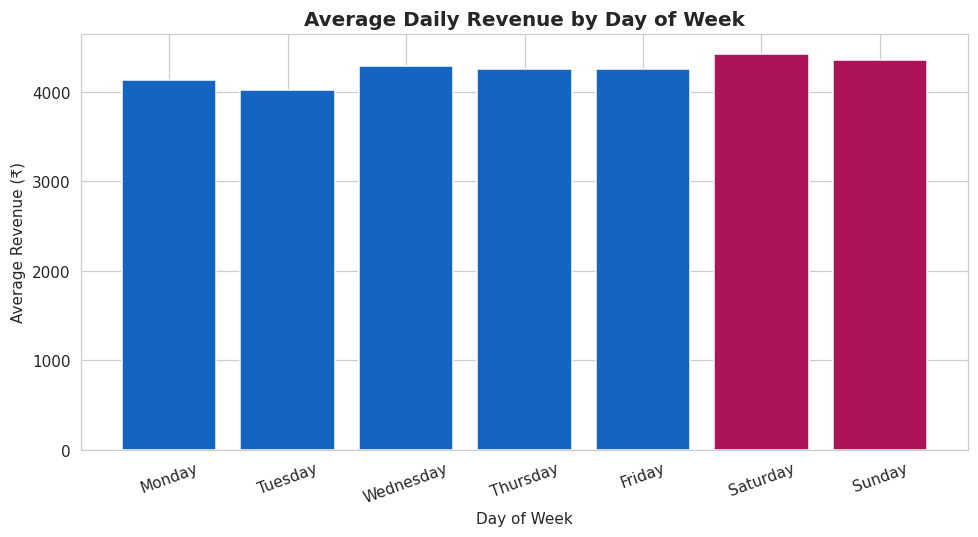

In [6]:
# Bar chart of average revenue per transaction by day of week (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#ad1457" if day in ("Saturday", "Sunday") else "#1565c0" for day in weekday_order]
ax.bar(weekday_order, avg_daily_revenue_by_weekday.values, color=colors)
ax.set_title("Average Daily Revenue by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Revenue (\u20b9)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [7]:
# Total revenue by month, across the full 6-month window.
monthly_total_revenue = df.groupby("month")["revenue"].sum()
monthly_total_revenue


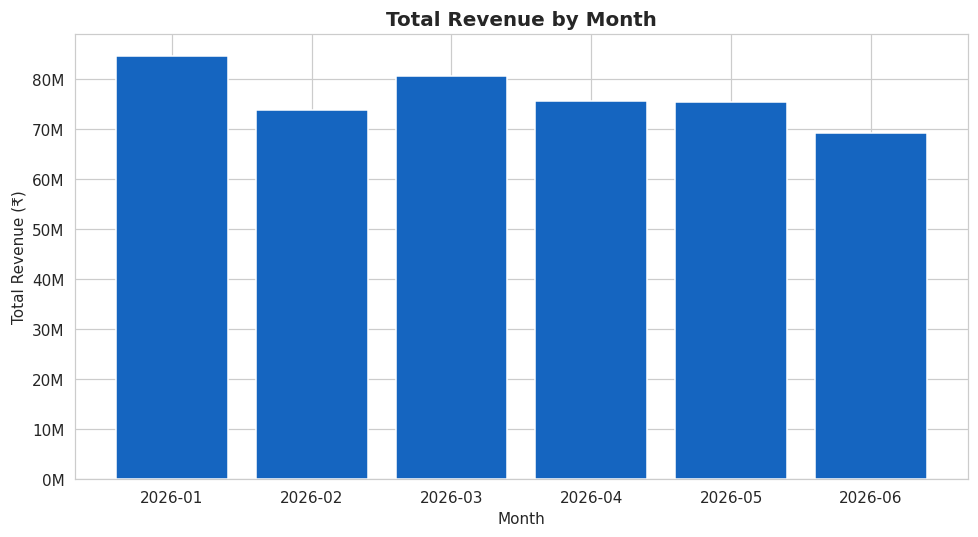

In [8]:
# Bar chart of total revenue by month (pink + blue only).
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(monthly_total_revenue.index, monthly_total_revenue.values, color="#1565c0")
ax.set_title("Total Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (\u20b9)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
plt.tight_layout()
plt.show()


In [9]:
# Identify best/worst day and month, and Electronics' monthly share of total revenue.
best_day = avg_daily_revenue_by_weekday.idxmax()
worst_day = avg_daily_revenue_by_weekday.idxmin()
best_month = monthly_total_revenue.idxmax()
worst_month = monthly_total_revenue.idxmin()

print(f"Best day (avg revenue/transaction): {best_day} (\u20b9{avg_daily_revenue_by_weekday.max():,.0f})")
print(f"Worst day (avg revenue/transaction): {worst_day} (\u20b9{avg_daily_revenue_by_weekday.min():,.0f})")
print(f"Best month (total revenue): {best_month} (\u20b9{monthly_total_revenue.max():,.0f})")
print(f"Worst month (total revenue): {worst_month} (\u20b9{monthly_total_revenue.min():,.0f})")

electronics_share_by_month = (
    df[df["category"] == "Electronics"].groupby("month")["revenue"].sum() / monthly_total_revenue * 100
)
print()
print("Electronics share of total monthly revenue:")
print(electronics_share_by_month.round(1))


Best day (avg revenue/transaction): Saturday (₹4,420)
Worst day (avg revenue/transaction): Tuesday (₹4,018)
Best month (total revenue): 2026-01 (₹84,768,131)
Worst month (total revenue): 2026-06 (₹69,282,134)

Electronics share of total monthly revenue:
month
2026-01   53.90
2026-02   52.80
2026-03   50.60
2026-04   49.00
2026-05   45.30
2026-06   42.80
Name: revenue, dtype: float64


### Business Interpretation
**Saturday and Sunday are the strongest days**, both in total weekend revenue and in average revenue
per transaction, while **Tuesday is consistently the weakest**. This is a normal retail weekly pattern
and suggests promotional pushes and supplier-funded campaigns are best timed to launch just before the
weekend, riding the natural traffic peak rather than mid-week.

**January is the strongest month and June the weakest** — total chain revenue declines steadily across
the window. Tracking Electronics' share of monthly revenue alongside this shows the category's decline
outpacing the overall chain slowdown: Electronics' share of total revenue drops every single month,
confirming it is not simply following a general seasonal dip but genuinely losing ground relative to
the rest of the business.